In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

In [ ]:
SCRIPT_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Plots will be saved to: {OUTPUT_DIR}")

Plots will be saved to: /content/outputs


In [ ]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income'
]

# Try loading from the UCI repository
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
try:
    df = pd.read_csv(DATA_URL, names=column_names, sep=r',\s*', engine='python', na_values='?')
    print(f"Dataset loaded from UCI repository. Shape: {df.shape}")
except Exception as e:
    print(f"Could not download dataset ({e}). Using sklearn fallback...")
    from sklearn.datasets import fetch_openml
    adult = fetch_openml(name='adult', version=2, as_frame=True)
    df = adult.frame
    # Rename target column to 'income'
    df = df.rename(columns={df.columns[-1]: 'income'})
    print(f"Dataset loaded via sklearn. Shape: {df.shape}")

# Display basic information
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nTarget distribution:\n{df['income'].value_counts()}")


Dataset loaded from UCI repository. Shape: (32561, 15)

Dataset shape: (32561, 15)

First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          217

In [ ]:
# -- 4a. Handle Missing Values --
print("\nMissing values per column:")
print(df.isnull().sum())

# Fill missing values with the mode (most frequent value) for each column
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:", df.isnull().sum().sum())

# -- 4b. Encode the Target Variable --
# Convert income to binary: 1 if >50K, 0 if <=50K
df['income'] = df['income'].astype(str).str.strip().str.replace('.', '', regex=False)
df['income'] = (df['income'] == '>50K').astype(int)
print(f"\nEncoded target distribution:\n{df['income'].value_counts()}")

# -- 4c. Separate Features and Target --
X = df.drop('income', axis=1)
y = df['income'].values

# -- 4d. Encode Categorical Features --
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Label encode categorical columns, then one-hot encode
# Using get_dummies for one-hot encoding (simpler and effective)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nFeature matrix shape after one-hot encoding: {X.shape}")

# -- 4e. Feature Scaling --
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled using StandardScaler.")

# -- 4f. Train-Test Split --
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

input_dim = X_train.shape[1]
print(f"Number of input features: {input_dim}")


Missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
Missing values after imputation: 0

Encoded target distribution:
income
0    24720
1     7841
Name: count, dtype: int64

Categorical columns (8): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numerical columns (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Feature matrix shape after one-hot encoding: (32561, 97)


/tmp/ipykernel_2585/1210593840.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Features scaled using StandardScaler.

Training set size: 26048
Test set size:     6513
Number of input features: 97


In [ ]:

def build_regularized_model(input_dim):

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001), name='hidden_1'),
        Dropout(0.3, name='dropout_1'),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001), name='hidden_2'),
        Dropout(0.3, name='dropout_2'),
        Dense(1, activation='sigmoid', name='output')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v2 = build_regularized_model(input_dim)
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865 (81.50 KB)

 Trainable params: 20,865 (81.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_baseline_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu', name='hidden_1'),
        Dense(64, activation='relu', name='hidden_2'),
        Dense(1, activation='sigmoid', name='output')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v1 = build_baseline_model(input_dim)
model_v1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865 (81.50 KB)

 Trainable params: 20,865 (81.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

# Early stopping to prevent unnecessary training
early_stop = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)

# -- Train Model v1 (Baseline) --
print("\n--- Training Model v1 (Baseline) ---")
history_v1 = model_v1.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

# -- Train Model v2 (Regularized) --
print("\n--- Training Model v2 (Regularized) ---")
# Reset early stopping
early_stop_v2 = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)

history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=[early_stop_v2],
    verbose=1
)


--- Training Model v1 (Baseline) ---
Epoch 1/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8359 - loss: 0.3533 - val_accuracy: 0.8407 - val_loss: 0.3389
Epoch 2/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8525 - loss: 0.3155 - val_accuracy: 0.8447 - val_loss: 0.3314
Epoch 3/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8579 - loss: 0.3061 - val_accuracy: 0.8455 - val_loss: 0.3288
Epoch 4/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8595 - loss: 0.2997 - val_accuracy: 0.8417 - val_loss: 0.3289
Epoch 5/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.2936 - val_accuracy: 0.8443 - val_loss: 0.3375
Epoch 6/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8661 - loss: 0.2896 - val_accuracy: 0.8463 - val_loss: 0.3308
Epoch 7/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8659 - loss: 0.2856 - val_accuracy: 0.8453 - val_loss: 0.3377
Epoch 8/50
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.

In [ ]:
# -- Evaluate Model v1 --
print("\n--- Model v1 (Baseline) ---")
loss_v1, acc_v1 = model_v1.evaluate(X_test, y_test, verbose=0)
y_pred_v1 = (model_v1.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print(f"Test Loss: {loss_v1:.4f}")
print(f"Test Accuracy: {acc_v1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_v1, target_names=['<=50K', '>50K']))

# -- Evaluate Model v2 --
print("\n--- Model v2 (Regularized) ---")
loss_v2, acc_v2 = model_v2.evaluate(X_test, y_test, verbose=0)
y_pred_v2 = (model_v2.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print(f"Test Loss: {loss_v2:.4f}")
print(f"Test Accuracy: {acc_v2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_v2, target_names=['<=50K', '>50K']))

# -- Comparison Table --
print("\n" + "-"*40)
print("MODEL COMPARISON")
print("-"*40)
print(f"{'Model':<25} {'Test Accuracy':<15} {'Test Loss'}")
print(f"{'Baseline (v1)':<25} {acc_v1:<15.4f} {loss_v1:.4f}")
print(f"{'Regularized (v2)':<25} {acc_v2:<15.4f} {loss_v2:.4f}")


--- Model v1 (Baseline) ---
Test Loss: 0.3184
Test Accuracy: 0.8541

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.91      0.90      4945
        >50K       0.70      0.68      0.69      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.80      0.80      6513
weighted avg       0.85      0.85      0.85      6513


--- Model v2 (Regularized) ---
Test Loss: 0.3263
Test Accuracy: 0.8578

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4945
        >50K       0.75      0.61      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.82      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513


----------------------------------------
MODEL COMPARISON
----------------------------------------
Model                     Test Accuracy   Test Loss
Basel

In [ ]:
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# -- Plot 1: Training & Validation Accuracy (Both Models) --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Model v1
axes[0].plot(history_v1.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_v1.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Model v1 (Baseline) — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Model v2
axes[1].plot(history_v2.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_v2.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('Model v2 (Regularized) — Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnn_accuracy_curves.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fnn_accuracy_curves.png")

# -- Plot 2: Training & Validation Loss (Both Models) --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_v1.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_v1.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('Model v1 (Baseline) — Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_v2.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_v2.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Model v2 (Regularized) — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnn_loss_curves.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fnn_loss_curves.png")

# -- Plot 3: Confusion Matrices --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model v1 confusion matrix
cm_v1 = confusion_matrix(y_test, y_pred_v1)
sns.heatmap(cm_v1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_title('Model v1 (Baseline) — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Model v2 confusion matrix
cm_v2 = confusion_matrix(y_test, y_pred_v2)
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[1].set_title('Model v2 (Regularized) — Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnn_confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fnn_confusion_matrices.png")

Saved: fnn_accuracy_curves.png
Saved: fnn_loss_curves.png
Saved: fnn_confusion_matrices.png


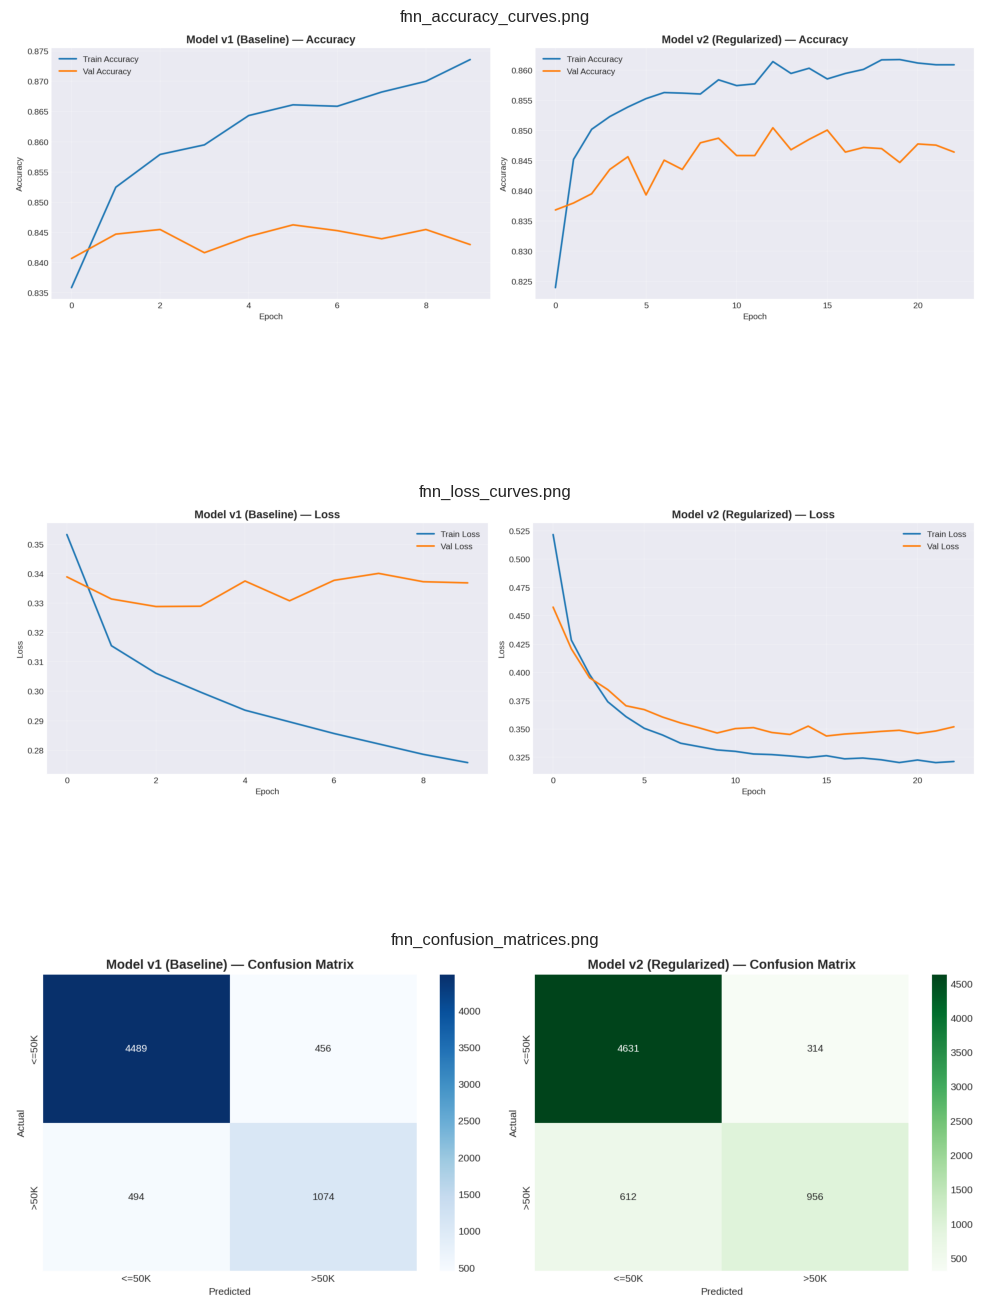

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of image filenames to display
image_files = [
    "fnn_accuracy_curves.png",
    "fnn_loss_curves.png",
    "fnn_confusion_matrices.png"
]

plt.figure(figsize=(10, 15))

for i, img_file in enumerate(image_files):
    img_path = os.path.join(OUTPUT_DIR, img_file)
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.subplot(len(image_files), 1, i + 1)
        plt.imshow(img)
        plt.title(img_file)
        plt.axis('off') # Hide axes
    else:
        print(f"Image file not found: {img_path}")

plt.tight_layout()
plt.show()